# CLUSTERING PRODUCTOS

## Justificación de las variables seleccionadas

El objetivo del clustering es agrupar productos con comportamiento similar para que la empresa 
pueda tomar decisiones de negocio más informadas. Las variables seleccionadas se han elegido 
pensando en las necesidades operativas del retailer:

- **Distribución de ventas por trimestre y región** (Q1–Q4 × Boston/NY/Philly): conocer en qué 
trimestres y regiones se concentran las ventas de cada producto permite a la empresa anticipar 
la demanda, optimizar el stock por almacén y planificar campañas de marketing estacionales.

- **Precio medio y coeficiente de variación del precio** (precio_cv): identificar productos con 
precio estable vs productos con precio muy variable ayuda a diseñar estrategias de pricing 
diferenciadas por grupo.

- **Descuento medio y primer descuento**: capturan la estrategia promocional de cada producto. 
Productos que necesitan descuentos frecuentes o tempranos para venderse tienen un perfil de 
demanda distinto a los que mantienen precio.

- **Ticket medio**: distingue productos de alto valor comprados con poca frecuencia de productos 
baratos de alta rotación, dos perfiles con necesidades logísticas muy diferentes.

- **Coeficiente de variación de ventas** (ventas_cv): mide la irregularidad de la demanda. 
Productos con demanda muy variable requieren más stock de seguridad que productos con ventas 
estables.

- **% ventas en fin de semana y festivos**: permite identificar productos de consumo de ocio 
o estacionales, útil para planificar refuerzos de stock en esos períodos.

- **Regionalidad**: un índice que mide si el producto se vende de forma homogénea en todas las 
regiones o está concentrado en una. Relevante para decidir qué productos distribuir de forma 
centralizada vs local.

In [3]:
import pandas as pd

In [4]:
df = pd.read_feather('data_dsmarket/df_preprocessed.feather')

In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df.head()

,id,item,category,department,store,store_code,region,d,sales,weekday,event,yearweek,sell_price,season,ingresos,is_holiday
date,,,,,,,,,,,,,,,,
2011-01-29,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_1,0,Saturday,None,201105.0,12.7414,Invierno,0.0,0
2011-01-30,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_2,0,Sunday,None,201105.0,12.7414,Invierno,0.0,0
2011-01-31,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_3,0,Monday,None,201105.0,12.7414,Invierno,0.0,0
2011-02-01,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_4,0,Tuesday,None,201105.0,12.7414,Invierno,0.0,0
2011-02-02,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_5,0,Wednesday,None,201105.0,12.7414,Invierno,0.0,0


Vamos a crear algunas variabels como porcentaje de ventas por region, precio medio por producto, unidades vendidas de cada producto

In [6]:
#para cada region separamos los datos, creamos una nueva columna 'quarter' que indica el trimestre del año, y luego usamos pd.crosstab para calcular la suma de las ventas totales por artículo y trimestre. Finalmente, renombramos las columnas para que sean más descriptivas y restablecemos el índice para que 'item' vuelva a ser una columna normal.
regions = df['region'].unique()
dfs = []
for region in regions:
    df_region = df[df['region'] == region].copy()
    df_region['quarter'] = df_region.index.quarter 
    df_region = pd.crosstab(df_region['item'], df_region['quarter'], values=df_region['ingresos'], aggfunc='sum', normalize='index')
    df_region.columns = [f'{region}_Trimestre{col}' for col in df_region.columns]
    df_region.reset_index(inplace=True)
    dfs.append(df_region)

In [7]:
display(dfs[0])
display(dfs[1])
display(dfs[2])

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312
...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.295176,0.179518,0.220741,0.304565
3045,SUPERMARKET_3_824,0.231428,0.277663,0.314298,0.176611
3046,SUPERMARKET_3_825,0.327716,0.257542,0.228880,0.185862
3047,SUPERMARKET_3_826,0.267169,0.296489,0.224461,0.211881


,item,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4
0,ACCESORIES_1_001,0.292514,0.182852,0.230936,0.293697
1,ACCESORIES_1_002,0.175182,0.190535,0.264493,0.369789
2,ACCESORIES_1_003,0.292750,0.247606,0.187415,0.272230
3,ACCESORIES_1_004,0.270005,0.255676,0.228044,0.246275
4,ACCESORIES_1_005,0.242563,0.202705,0.268171,0.286560
...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.284794,0.206293,0.276591,0.232322
3045,SUPERMARKET_3_824,0.230905,0.341688,0.225210,0.202197
3046,SUPERMARKET_3_825,0.279459,0.231081,0.289807,0.199653
3047,SUPERMARKET_3_826,0.249489,0.296864,0.250511,0.203136


,item,Philadelphia_Trimestre1,Philadelphia_Trimestre2,Philadelphia_Trimestre3,Philadelphia_Trimestre4
0,ACCESORIES_1_001,0.287250,0.192133,0.246951,0.273666
1,ACCESORIES_1_002,0.218956,0.177950,0.248356,0.354739
2,ACCESORIES_1_003,0.331651,0.256824,0.221132,0.190392
3,ACCESORIES_1_004,0.289951,0.262349,0.219520,0.228180
4,ACCESORIES_1_005,0.266457,0.193219,0.214482,0.325841
...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.310139,0.195423,0.223259,0.271178
3045,SUPERMARKET_3_824,0.228849,0.326637,0.283443,0.161072
3046,SUPERMARKET_3_825,0.327534,0.246164,0.226106,0.200195
3047,SUPERMARKET_3_826,0.215217,0.293422,0.249470,0.241891


In [8]:
# unimos los 3 dataframes resultantes en uno solo usando pd.merge, asegurándonos de mantener la columna 'item' como clave de unión. Luego, calculamos el total de unidades vendidas por 'item' y el precio medio total por 'item', y realizamos merges adicionales para agregar esta información al dataframe final.
df_merge = pd.merge(dfs[0], dfs[1], on='item', how='outer')
df_merge = pd.merge(df_merge, dfs[2], on='item', how='outer')

In [9]:
total_sales_by_item = df.groupby('item')['sales'].sum().reset_index(name='unidades vendidas')
average_price_by_item = df.groupby('item')['sell_price'].mean().reset_index(name='precio medio total')
df_merge = pd.merge(df_merge, total_sales_by_item, on='item', how='left')
df_final_item_region = pd.merge(df_merge, average_price_by_item, on='item', how='left')
df_final_item_region.head()

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Philadelphia_Trimestre1,Philadelphia_Trimestre2,Philadelphia_Trimestre3,Philadelphia_Trimestre4,unidades vendidas,precio medio total
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840,0.292514,0.182852,0.230936,0.293697,0.287250,0.192133,0.246951,0.273666,4093,11.468528
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795,0.175182,0.190535,0.264493,0.369789,0.218956,0.177950,0.248356,0.354739,5059,5.276737
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837,0.292750,0.247606,0.187415,0.272230,0.331651,0.256824,0.221132,0.190392,1435,3.947623
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044,0.270005,0.255676,0.228044,0.246275,0.289951,0.262349,0.219520,0.228180,39175,5.978931
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312,0.242563,0.202705,0.268171,0.286560,0.266457,0.193219,0.214482,0.325841,14621,3.837978


In [10]:
# añadimos las ventas por trimestre en general para cada artículo, sin segmentar por región, y luego calculamos el precio medio total por artículo. Finalmente, realizamos merges adicionales para agregar esta información al dataframe final.
total_sales_by_quarter = (df.groupby(['item', df.index.quarter.rename('quarter')])['sales'].sum().unstack('quarter').rename(columns={1: 'Q1_total', 2: 'Q2_total', 3: 'Q3_total', 4: 'Q4_total'}).reset_index())
q_cols = ['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total']
total_sales_by_quarter[q_cols] = total_sales_by_quarter[q_cols].div( total_sales_by_quarter[q_cols].sum(axis=1), axis=0)
df_final_item_region = pd.merge(df_final_item_region, total_sales_by_quarter, on='item', how='left')

In [11]:
df_final_item_region

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Philadelphia_Trimestre1,Philadelphia_Trimestre2,Philadelphia_Trimestre3,Philadelphia_Trimestre4,unidades vendidas,precio medio total,Q1_total,Q2_total,Q3_total,Q4_total
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840,0.292514,0.182852,0.230936,0.293697,0.287250,0.192133,0.246951,0.273666,4093,11.468528,0.284144,0.190569,0.232348,0.292939
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795,0.175182,0.190535,0.264493,0.369789,0.218956,0.177950,0.248356,0.354739,5059,5.276737,0.202807,0.192924,0.255584,0.348686
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837,0.292750,0.247606,0.187415,0.272230,0.331651,0.256824,0.221132,0.190392,1435,3.947623,0.294077,0.250174,0.221603,0.234146
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044,0.270005,0.255676,0.228044,0.246275,0.289951,0.262349,0.219520,0.228180,39175,5.978931,0.270989,0.257792,0.228156,0.243063
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312,0.242563,0.202705,0.268171,0.286560,0.266457,0.193219,0.214482,0.325841,14621,3.837978,0.238903,0.201423,0.253881,0.305793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.295176,0.179518,0.220741,0.304565,0.284794,0.206293,0.276591,0.232322,0.310139,0.195423,0.223259,0.271178,15388,3.345946,0.290421,0.195347,0.249480,0.264752
3045,SUPERMARKET_3_824,0.231428,0.277663,0.314298,0.176611,0.230905,0.341688,0.225210,0.202197,0.228849,0.326637,0.283443,0.161072,8325,3.026945,0.230390,0.322763,0.259580,0.187267
3046,SUPERMARKET_3_825,0.327716,0.257542,0.228880,0.185862,0.279459,0.231081,0.289807,0.199653,0.327534,0.246164,0.226106,0.200195,13526,4.934213,0.304894,0.240869,0.259944,0.194292
3047,SUPERMARKET_3_826,0.267169,0.296489,0.224461,0.211881,0.249489,0.296864,0.250511,0.203136,0.215217,0.293422,0.249470,0.241891,12188,1.535877,0.244585,0.295865,0.243764,0.215786


In [12]:
precio_stats = df.groupby('item')['sell_price'].agg(['mean', 'std']).reset_index()
precio_stats.columns = ['item', 'precio_medio', 'precio_std']
precio_stats['precio_cv'] = precio_stats['precio_std'] / precio_stats['precio_medio']

# Primer descuento (bajada >5% semana a semana)
precios_semanales = df.groupby(['item', df.index.to_period('W')])['sell_price'].mean().reset_index()
precios_semanales.columns = ['item', 'week', 'precio']
precios_semanales = precios_semanales.sort_values(['item', 'week'])
precios_semanales['precio_anterior'] = precios_semanales.groupby('item')['precio'].shift(1)
precios_semanales['descuento'] = (precios_semanales['precio_anterior'] - precios_semanales['precio']) / precios_semanales['precio_anterior']
precios_semanales['descuento'] = precios_semanales['descuento'].where(precios_semanales['descuento'] > 0.05, 0)

primer_descuento = (
    precios_semanales[precios_semanales['descuento'] > 0]
    .sort_values('week')
    .groupby('item')
    .first()
    .reset_index()[['item', 'descuento']]
    .rename(columns={'descuento': 'primer_descuento'})
)
primer_descuento['primer_descuento'] = primer_descuento['primer_descuento'].fillna(0)


In [13]:
primer_descuento.sort_values('primer_descuento', ascending=False)

,item,primer_descuento
2934,SUPERMARKET_3_711,0.222222
3031,SUPERMARKET_3_810,0.208861
2849,SUPERMARKET_3_625,0.165433
2254,SUPERMARKET_3_029,0.156888
2443,SUPERMARKET_3_219,0.156888
...,...,...
1108,HOME_&_GARDEN_2_012,0.000000
1110,HOME_&_GARDEN_2_014,0.000000
1111,HOME_&_GARDEN_2_015,0.000000
1113,HOME_&_GARDEN_2_017,0.000000


In [14]:
precio_stats

,item,precio_medio,precio_std,precio_cv
0,ACCESORIES_1_001,11.468528,0.735440,0.064127
1,ACCESORIES_1_002,5.276737,0.090401,0.017132
2,ACCESORIES_1_003,3.947623,0.128106,0.032452
3,ACCESORIES_1_004,5.978931,0.277244,0.046370
4,ACCESORIES_1_005,3.837978,0.223108,0.058132
...,...,...,...,...
3044,SUPERMARKET_3_823,3.345946,0.225852,0.067500
3045,SUPERMARKET_3_824,3.026945,0.256036,0.084586
3046,SUPERMARKET_3_825,4.934213,0.241812,0.049007
3047,SUPERMARKET_3_826,1.535877,0.006426,0.004184


In [15]:
# Ticket medio (ingresos / nº semanas con ventas)
demanda = df.groupby(['item', df.index.to_period('W')]).agg(
    ventas=('sales', 'sum'),
    ingresos=('ingresos', 'sum')
).reset_index()

ticket_medio = (
    demanda[demanda['ventas'] > 0]
    .groupby('item')
    .apply(lambda x: x['ingresos'].sum() / len(x))
    .reset_index(name='ticket_medio')
)

ventas_cv = (
    demanda.groupby('item')['ventas']
    .agg(['mean', 'std'])
    .reset_index()
    .assign(ventas_cv=lambda x: x['std'] / x['mean'])[['item', 'ventas_cv']]
)

In [16]:
ventas_cv

,item,ventas_cv
0,ACCESORIES_1_001,1.028183
1,ACCESORIES_1_002,0.574104
2,ACCESORIES_1_003,1.470853
3,ACCESORIES_1_004,0.218073
4,ACCESORIES_1_005,0.463014
...,...,...
3044,SUPERMARKET_3_823,0.828115
3045,SUPERMARKET_3_824,0.679294
3046,SUPERMARKET_3_825,0.643982
3047,SUPERMARKET_3_826,0.905057


In [17]:
ticket_medio

,item,ticket_medio
0,ACCESORIES_1_001,310.605280
1,ACCESORIES_1_002,103.922468
2,ACCESORIES_1_003,51.421307
3,ACCESORIES_1_004,859.004448
4,ACCESORIES_1_005,214.104312
...,...,...
3044,SUPERMARKET_3_823,244.642315
3045,SUPERMARKET_3_824,104.166344
3046,SUPERMARKET_3_825,274.184961
3047,SUPERMARKET_3_826,117.000598


In [18]:
ventas_findes = df[df.index.weekday >= 5].groupby('item')['sales'].sum().reset_index(name='ventas_fines_semana')
# ventas_findes
ventas_total = df.groupby('item')['sales'].sum().reset_index(name='ventas_total')
porcentaje_findes = pd.merge(ventas_findes, ventas_total, on='item', how='left')
# porcentaje_findes
porcentaje_findes['porcentaje_findes'] = porcentaje_findes['ventas_fines_semana'] / porcentaje_findes['ventas_total']

In [19]:
porcentaje_findes

,item,ventas_fines_semana,ventas_total,porcentaje_findes
0,ACCESORIES_1_001,1362,4093,0.332763
1,ACCESORIES_1_002,1777,5059,0.351255
2,ACCESORIES_1_003,544,1435,0.379094
3,ACCESORIES_1_004,14098,39175,0.359872
4,ACCESORIES_1_005,5250,14621,0.359073
...,...,...,...,...
3044,SUPERMARKET_3_823,5363,15388,0.348518
3045,SUPERMARKET_3_824,2768,8325,0.332492
3046,SUPERMARKET_3_825,4707,13526,0.347996
3047,SUPERMARKET_3_826,3745,12188,0.307269


In [20]:
ventas_festivos = df[df['is_holiday']== True].groupby('item')['sales'].sum().reset_index(name='ventas_festivos')
# ventas_festivos
ventas_total = df.groupby('item')['sales'].sum().reset_index(name='ventas_total')
porcentaje_festivos = pd.merge(ventas_festivos, ventas_total, on='item', how='left')
porcentaje_festivos['porcentaje_festivos'] = porcentaje_festivos['ventas_festivos'] / porcentaje_festivos['ventas_total']

In [21]:
porcentaje_festivos.sort_values('porcentaje_festivos', ascending=False)

,item,ventas_festivos,ventas_total,porcentaje_festivos
2787,SUPERMARKET_3_563,105,1928,0.054461
2216,SUPERMARKET_2_390,86,1605,0.053583
2163,SUPERMARKET_2_337,129,2455,0.052546
1923,SUPERMARKET_2_096,67,1282,0.052262
2454,SUPERMARKET_3_230,2492,48713,0.051157
...,...,...,...,...
135,ACCESORIES_1_140,95,5034,0.018872
1401,HOME_&_GARDEN_2_306,29,1560,0.018590
510,ACCESORIES_2_095,25,1396,0.017908
446,ACCESORIES_2_031,17,971,0.017508


In [22]:
# unimos todos los dfs que hemos idio construyendo
df_final_item_region = pd.merge( df_final_item_region, precio_stats[['item', 'precio_std', 'precio_cv']], on='item', how='left') # ya teniamos la del precio medio
df_final_item_region = pd.merge(df_final_item_region, primer_descuento, on='item', how='left')
df_final_item_region = pd.merge(df_final_item_region, ticket_medio, on='item', how='left')
df_final_item_region = pd.merge(df_final_item_region, ventas_cv, on='item', how='left')
df_final_item_region = pd.merge(df_final_item_region, porcentaje_findes[['item', 'porcentaje_findes']], on='item', how='left')
df_final_item_region = pd.merge(df_final_item_region, porcentaje_festivos[['item', 'porcentaje_festivos']], on='item', how='left')
df_final_item_region 

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Philadelphia_Trimestre1,...,Q2_total,Q3_total,Q4_total,precio_std,precio_cv,primer_descuento,ticket_medio,ventas_cv,porcentaje_findes,porcentaje_festivos
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840,0.292514,0.182852,0.230936,0.293697,0.287250,...,0.190569,0.232348,0.292939,0.735440,0.064127,0.000000,310.605280,1.028183,0.332763,0.037137
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795,0.175182,0.190535,0.264493,0.369789,0.218956,...,0.192924,0.255584,0.348686,0.090401,0.017132,0.000000,103.922468,0.574104,0.351255,0.026883
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837,0.292750,0.247606,0.187415,0.272230,0.331651,...,0.250174,0.221603,0.234146,0.128106,0.032452,0.067295,51.421307,1.470853,0.379094,0.034843
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044,0.270005,0.255676,0.228044,0.246275,0.289951,...,0.257792,0.228156,0.243063,0.277244,0.046370,0.000000,859.004448,0.218073,0.359872,0.032929
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312,0.242563,0.202705,0.268171,0.286560,0.266457,...,0.201423,0.253881,0.305793,0.223108,0.058132,0.071023,214.104312,0.463014,0.359073,0.032829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.295176,0.179518,0.220741,0.304565,0.284794,0.206293,0.276591,0.232322,0.310139,...,0.195347,0.249480,0.264752,0.225852,0.067500,0.057835,244.642315,0.828115,0.348518,0.029958
3045,SUPERMARKET_3_824,0.231428,0.277663,0.314298,0.176611,0.230905,0.341688,0.225210,0.202197,0.228849,...,0.322763,0.259580,0.187267,0.256036,0.084586,0.000000,104.166344,0.679294,0.332492,0.029309
3046,SUPERMARKET_3_825,0.327716,0.257542,0.228880,0.185862,0.279459,0.231081,0.289807,0.199653,0.327534,...,0.240869,0.259944,0.194292,0.241812,0.049007,0.062099,274.184961,0.643982,0.347996,0.030756
3047,SUPERMARKET_3_826,0.267169,0.296489,0.224461,0.211881,0.249489,0.296864,0.250511,0.203136,0.215217,...,0.295865,0.243764,0.215786,0.006426,0.004184,0.000000,117.000598,0.905057,0.307269,0.027650


In [23]:
ventas_region = df.groupby(['item', 'region'])['ingresos'].sum().reset_index()
ventas_region['ingresos_norm'] = ventas_region.groupby('item')['ingresos'].transform(lambda x: x / x.sum())
ventas_region_pivot = ventas_region.pivot(index='item', columns='region', values='ingresos_norm').reset_index()
ventas_region_pivot['regionalidad'] = ventas_region_pivot.iloc[:, 1:].max(axis=1) - ventas_region_pivot.iloc[:, 1:].min(axis=1)
regionalidad = ventas_region_pivot[['item', 'regionalidad']]

df_final_item_region = pd.merge(df_final_item_region, regionalidad, on='item', how='left')



Regionalidad baja (~0) → producto de distribución uniforme, se puede gestionar de forma centralizada


Regionalidad alta (~1) → producto muy local, tiene sentido gestionar su stock de forma independiente por región



El más bajo que se ve es 0.07 → producto que se vende casi igual en las 3 regiones

Los más altos rondan 0.49 → producto donde una región vende casi el doble que otra

In [24]:
df_final_item_region

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Philadelphia_Trimestre1,...,Q3_total,Q4_total,precio_std,precio_cv,primer_descuento,ticket_medio,ventas_cv,porcentaje_findes,porcentaje_festivos,regionalidad
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840,0.292514,0.182852,0.230936,0.293697,0.287250,...,0.232348,0.292939,0.735440,0.064127,0.000000,310.605280,1.028183,0.332763,0.037137,0.493571
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795,0.175182,0.190535,0.264493,0.369789,0.218956,...,0.255584,0.348686,0.090401,0.017132,0.000000,103.922468,0.574104,0.351255,0.026883,0.337518
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837,0.292750,0.247606,0.187415,0.272230,0.331651,...,0.221603,0.234146,0.128106,0.032452,0.067295,51.421307,1.470853,0.379094,0.034843,0.283080
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044,0.270005,0.255676,0.228044,0.246275,0.289951,...,0.228156,0.243063,0.277244,0.046370,0.000000,859.004448,0.218073,0.359872,0.032929,0.416094
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312,0.242563,0.202705,0.268171,0.286560,0.266457,...,0.253881,0.305793,0.223108,0.058132,0.071023,214.104312,0.463014,0.359073,0.032829,0.315161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.295176,0.179518,0.220741,0.304565,0.284794,0.206293,0.276591,0.232322,0.310139,...,0.249480,0.264752,0.225852,0.067500,0.057835,244.642315,0.828115,0.348518,0.029958,0.522197
3045,SUPERMARKET_3_824,0.231428,0.277663,0.314298,0.176611,0.230905,0.341688,0.225210,0.202197,0.228849,...,0.259580,0.187267,0.256036,0.084586,0.000000,104.166344,0.679294,0.332492,0.029309,0.357495
3046,SUPERMARKET_3_825,0.327716,0.257542,0.228880,0.185862,0.279459,0.231081,0.289807,0.199653,0.327534,...,0.259944,0.194292,0.241812,0.049007,0.062099,274.184961,0.643982,0.347996,0.030756,0.191694
3047,SUPERMARKET_3_826,0.267169,0.296489,0.224461,0.211881,0.249489,0.296864,0.250511,0.203136,0.215217,...,0.243764,0.215786,0.006426,0.004184,0.000000,117.000598,0.905057,0.307269,0.027650,0.233635


In [25]:
df_final_item_region.isna().sum()

item                       0
Boston_Trimestre1          0
Boston_Trimestre2          0
Boston_Trimestre3          0
Boston_Trimestre4          0
New York_Trimestre1        0
New York_Trimestre2        0
New York_Trimestre3        0
New York_Trimestre4        0
Philadelphia_Trimestre1    0
Philadelphia_Trimestre2    0
Philadelphia_Trimestre3    0
Philadelphia_Trimestre4    0
unidades vendidas          0
precio medio total         0
Q1_total                   0
Q2_total                   0
Q3_total                   0
Q4_total                   0
precio_std                 0
precio_cv                  0
primer_descuento           0
ticket_medio               0
ventas_cv                  0
porcentaje_findes          0
porcentaje_festivos        0
regionalidad               0
dtype: int64

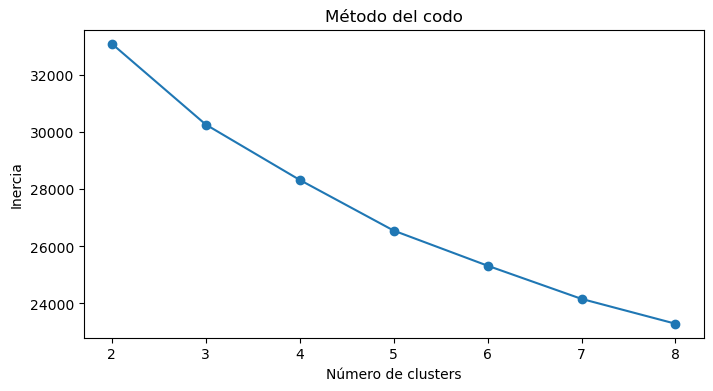

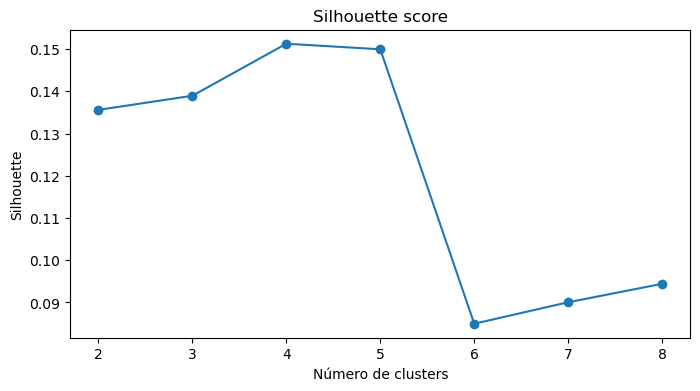

In [26]:
# ahora tendriamos que escalar las variables porque tenemos la del precio medio y cosas asi
from sklearn.preprocessing import StandardScaler
features = [
    'Q1_total', 'Q2_total', 'Q3_total', 'Q4_total',
    'precio medio total',
    'precio_cv',
    'primer_descuento',
    'ticket_medio',
    'ventas_cv',
    'porcentaje_findes',
    'porcentaje_festivos',
    'regionalidad'
] 
# todavia meto las mas genericas y luego ya la de losporcentajes con regiones
X = df_final_item_region[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(K_range, silhouette, marker='o')
plt.title("Silhouette score")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.show()

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import plotly.express as px

features = ['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total', 'precio medio total',
            'precio_cv', 'primer_descuento', 'ticket_medio', 'ventas_cv',
            'porcentaje_findes', 'porcentaje_festivos', 'regionalidad']

df_cluster = df_final_item_region.copy()
X = df_cluster[[c for c in features if c in df_cluster.columns]].copy()

for col in ['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total', 'ticket_medio']:
    if col in X.columns:
        X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=20)
labels_4 = kmeans_4.fit_predict(X_scaled)
df_cluster['cluster'] = labels_4

sil_score = silhouette_score(X_scaled, labels_4)
print(f"Silhouette score con 4 clusters: {sil_score:.4f}")
print("\nTamaño de cada cluster:")
print(df_cluster['cluster'].value_counts().sort_index())

resumen_clusters = df_cluster.groupby('cluster')[features].mean().round(2)
print("\nResumen de medias por cluster:")
display(resumen_clusters)

centroides_scaled = kmeans_4.cluster_centers_
centroides_df = pd.DataFrame(scaler.inverse_transform(centroides_scaled), columns=X.columns)
for col in ['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total', 'ticket_medio']:
    if col in centroides_df.columns:
        centroides_df[col] = np.expm1(centroides_df[col])
print("\nCentroides aproximados en escala original:")
display(centroides_df.round(2))

# apra poder pitnarlo hacemos pca para no tener q ver las 12 dimensiones, y luego hacemos un scatter plot con plotly para ver como quedan los clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = labels_4.astype(str)
if 'item' in df_cluster.columns:
    df_pca['item'] = df_cluster['item'].values

fig = px.scatter(df_pca, x='PC1', y='PC2', color='cluster',
                 hover_data=['item'] if 'item' in df_pca.columns else None,
                 title='Visualización de los 4 clusters (PCA)',
                 labels={'cluster': 'Cluster'},
                 opacity=0.7)
fig.show()

Silhouette score con 4 clusters: 0.1437

Tamaño de cada cluster:
0     183
1     615
2    1649
3     602
Name: cluster, dtype: int64

Resumen de medias por cluster:


,Q1_total,Q2_total,Q3_total,Q4_total,precio medio total,precio_cv,primer_descuento,ticket_medio,ventas_cv,porcentaje_findes,porcentaje_festivos,regionalidad
cluster,,,,,,,,,,,,
0,0.22,0.33,0.32,0.14,5.96,0.04,0.01,323.52,1.04,0.35,0.03,0.33
1,0.31,0.21,0.20,0.27,7.03,0.03,0.00,369.57,1.30,0.35,0.03,0.27
2,0.27,0.25,0.25,0.24,5.35,0.03,0.00,338.52,0.59,0.35,0.03,0.28
3,0.28,0.25,0.24,0.24,4.53,0.08,0.07,362.62,0.69,0.34,0.03,0.27



Centroides aproximados en escala original:


,Q1_total,Q2_total,Q3_total,Q4_total,precio medio total,precio_cv,primer_descuento,ticket_medio,ventas_cv,porcentaje_findes,porcentaje_festivos,regionalidad
0,0.21,0.33,0.31,0.13,5.96,0.04,0.01,213.42,1.04,0.35,0.03,0.33
1,0.31,0.21,0.20,0.27,7.03,0.03,0.00,200.44,1.30,0.35,0.03,0.27
2,0.27,0.25,0.25,0.24,5.35,0.03,0.00,211.48,0.59,0.35,0.03,0.28
3,0.28,0.24,0.24,0.24,4.53,0.08,0.07,223.43,0.69,0.34,0.03,0.27


In [32]:
# Perfil resumido de cada cluster
perfil = df_cluster.groupby('cluster')[features].agg(['mean', 'median']).round(2)
perfil.to_excel('perfil_clusters.xlsx')

In [34]:
for var in features:
    fig = px.box(df_cluster, x='cluster', y=var, color='cluster',
                 title=f'Distribución de {var} por cluster',
                 labels={'cluster': 'Cluster', var: var})
    fig.show()